In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Phase 1: Data Understanding

In [2]:
df = pd.read_csv('../Datasets/titanic/train.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
df.shape

(891, 12)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


Phase 2: Data Quality Check

In [6]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [7]:
missing = df.isnull().sum().sort_values(ascending=False)
print(missing)

Cabin          687
Age            177
Embarked         2
PassengerId      0
Name             0
Pclass           0
Survived         0
Sex              0
Parch            0
SibSp            0
Fare             0
Ticket           0
dtype: int64


In [8]:
df.duplicated().sum()

np.int64(0)

Phase 3: Exploratory Data Analysis (EDA)

In [9]:
df["Survived"].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

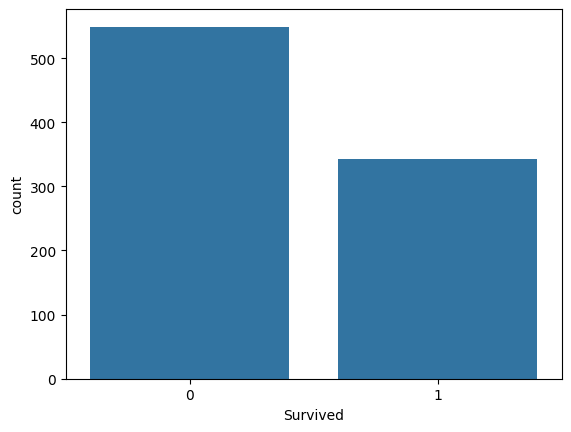

In [10]:
sns.countplot(data=df, x="Survived")
plt.show()

In [11]:
pd.crosstab(df["Sex"], df["Survived"])

Survived,0,1
Sex,,
female,81,233
male,468,109


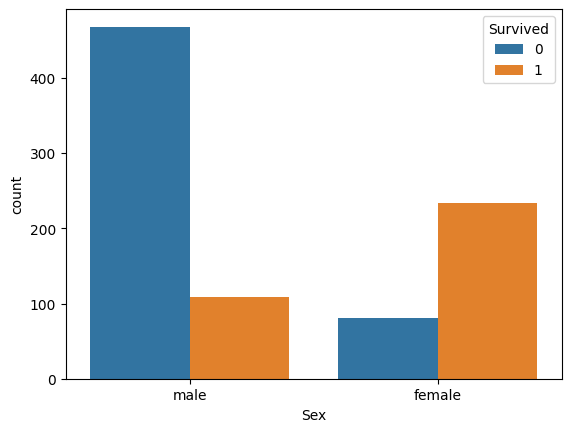

In [12]:
sns.countplot(
    data=df,
    x="Sex",
    hue="Survived"
)
plt.show()

In [13]:
df.groupby(["Pclass","Survived"]).size()

Pclass  Survived
1       0            80
        1           136
2       0            97
        1            87
3       0           372
        1           119
dtype: int64

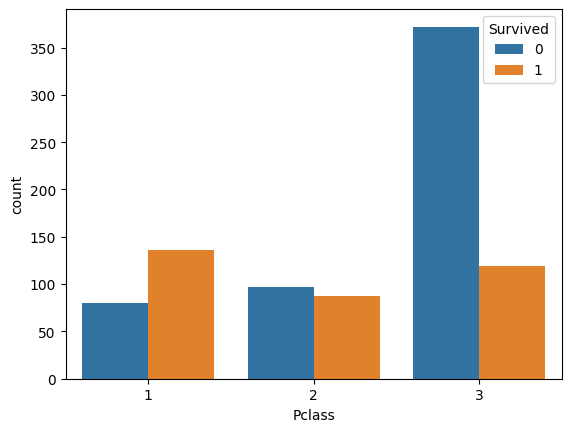

In [14]:
sns.countplot(
    data=df,
    x="Pclass",
    hue="Survived"
)
plt.show()

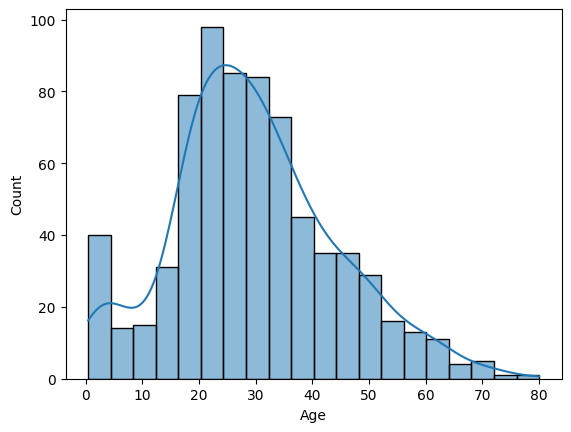

In [15]:
sns.histplot(
    df["Age"],
    kde=True
)
plt.show()

Phase 4: Data Cleaning

In [16]:
df["Age"].isnull().sum()

np.int64(177)

In [17]:
df["Age"] = df["Age"].fillna(df["Age"].median())

In [18]:
df["Embarked"].mode()

0    S
Name: Embarked, dtype: object

In [19]:
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

Feature Engineering

In [20]:
df["Cabin"].isnull().sum()

np.int64(687)

In [21]:
missing_pct = df["Cabin"].isnull().mean() * 100
print(f"Missing: {missing_pct:.2f}%")

Missing: 77.10%


In [22]:
df["Deck"] = df["Cabin"].str[0]

In [23]:
df["Deck"].value_counts(dropna=False)

Deck
NaN    687
C       59
B       47
D       33
E       32
A       15
F       13
G        4
T        1
Name: count, dtype: int64

In [24]:
df["Deck"] = df["Deck"].fillna("Unknown")

In [25]:
df["Deck"].value_counts()

Deck
Unknown    687
C           59
B           47
D           33
E           32
A           15
F           13
G            4
T            1
Name: count, dtype: int64

In [26]:
pd.crosstab(df["Deck"],df["Survived"])

Survived,0,1
Deck,,
A,8,7
B,12,35
C,24,35
D,8,25
E,8,24
F,5,8
G,2,2
T,1,0
Unknown,481,206


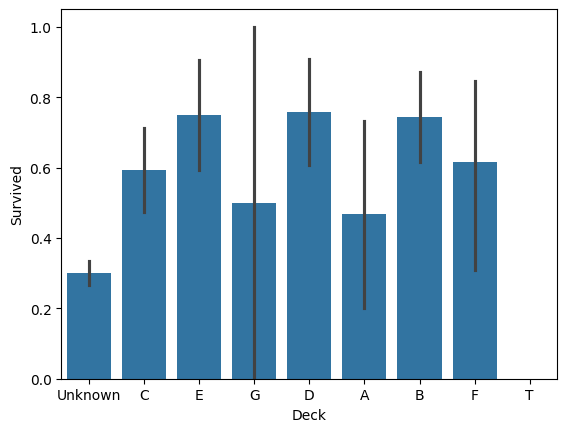

In [27]:
sns.barplot(
    data=df,
    x="Deck",
    y="Survived"
)

plt.show()

Task 14: Feature Engineering

In [28]:
df["FamilySize"] = (df["SibSp"] + df["Parch"] + 1)
df[["SibSp", "Parch", "FamilySize"]].head()

,SibSp,Parch,FamilySize
0,1,0,2
1,1,0,2
2,0,0,1
3,1,0,2
4,0,0,1


In [29]:
df["IsAlone"] = (df["FamilySize"] == 1).astype(int)
df[["FamilySize", "IsAlone"]].head()

,FamilySize,IsAlone
0,2,0
1,2,0
2,1,1
3,2,0
4,1,1


In [30]:
pd.crosstab(df["IsAlone"],df["Survived"])

Survived,0,1
IsAlone,,
0,175,179
1,374,163


In [31]:
df["IsAlone"].value_counts()

IsAlone
1    537
0    354
Name: count, dtype: int64

In [32]:
df["Name"].head()

0                              Braund, Mr. Owen Harris
1    Cumings, Mrs. John Bradley (Florence Briggs Th...
2                               Heikkinen, Miss. Laina
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)
4                             Allen, Mr. William Henry
Name: Name, dtype: object

In [33]:
df["Title"] = df["Name"].str.extract(' ([A-Za-z]+)\.', expand=False)

In [34]:
df["Title"].value_counts()

Title
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Col           2
Mlle          2
Major         2
Ms            1
Mme           1
Don           1
Lady          1
Sir           1
Capt          1
Countess      1
Jonkheer      1
Name: count, dtype: int64

In [35]:
rare_titles = [
    "Lady","Countess","Capt","Col",
    "Don","Dr","Major","Rev",
    "Sir","Jonkheer","Dona"
]

df["Title"] = df["Title"].replace(
    rare_titles,
    "Rare"
)

In [36]:
df["Title"] = df["Title"].replace(
    {
        "Mlle":"Miss",
        "Ms":"Miss",
        "Mme":"Mrs"
    }
)

In [37]:
df["Title"].value_counts()

Title
Mr        517
Miss      185
Mrs       126
Master     40
Rare       23
Name: count, dtype: int64

In [38]:
pd.crosstab(
    df["Title"],
    df["Survived"])

Survived,0,1
Title,,
Master,17,23
Miss,55,130
Mr,436,81
Mrs,26,100
Rare,15,8


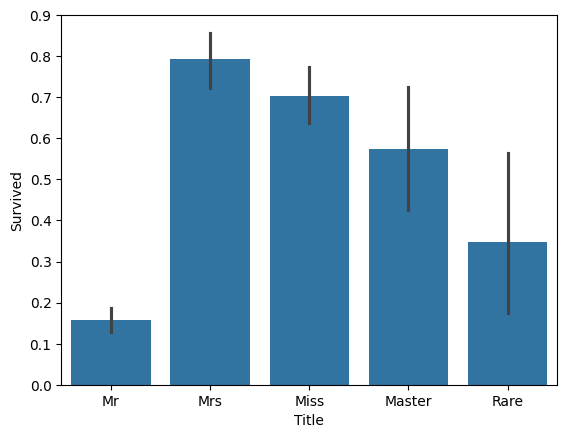

In [39]:
sns.barplot(
    data=df,
    x="Title",
    y="Survived"
)

plt.show()

In [40]:
drop_cols = [
    "PassengerId",
    "Name",
    "Ticket",
    "Cabin"
]

df.drop(
    columns=drop_cols,
    inplace=True,
    errors="ignore"
)

In [41]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Deck,FamilySize,IsAlone,Title
0,0,3,male,22.0,1,0,7.2500,S,Unknown,2,0,Mr
1,1,1,female,38.0,1,0,71.2833,C,C,2,0,Mrs
2,1,3,female,26.0,0,0,7.9250,S,Unknown,1,1,Miss
3,1,1,female,35.0,1,0,53.1000,S,C,2,0,Mrs
4,0,3,male,35.0,0,0,8.0500,S,Unknown,1,1,Mr


In [42]:
y = df["Survived"]

In [43]:
X = df.drop("Survived", axis=1)

In [44]:
print(X.shape)
print(y.shape)

(891, 11)
(891,)


Encode Categorical Variables

In [45]:
X.select_dtypes(include="object").columns

Index(['Sex', 'Embarked', 'Deck', 'Title'], dtype='object')

In [46]:
X = pd.get_dummies(
    X,
    drop_first=True
)

In [47]:
X.head()

,Pclass,Age,SibSp,Parch,Fare,FamilySize,IsAlone,Sex_male,Embarked_Q,Embarked_S,...,Deck_D,Deck_E,Deck_F,Deck_G,Deck_T,Deck_Unknown,Title_Miss,Title_Mr,Title_Mrs,Title_Rare
0,3,22.0,1,0,7.2500,2,0,True,False,True,...,False,False,False,False,False,True,False,True,False,False
1,1,38.0,1,0,71.2833,2,0,False,False,False,...,False,False,False,False,False,False,False,False,True,False
2,3,26.0,0,0,7.9250,1,1,False,False,True,...,False,False,False,False,False,True,True,False,False,False
3,1,35.0,1,0,53.1000,2,0,False,False,True,...,False,False,False,False,False,False,False,False,True,False
4,3,35.0,0,0,8.0500,1,1,True,False,True,...,False,False,False,False,False,True,False,True,False,False


In [48]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [49]:
print(X_train.shape)
print(X_test.shape)

(712, 22)
(179, 22)


In [50]:
numeric_cols = [
    "Age",
    "Fare",
    "FamilySize"
]

In [51]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train[numeric_cols] = scaler.fit_transform(
    X_train[numeric_cols]
)

X_test[numeric_cols] = scaler.transform(
    X_test[numeric_cols]
)

In [52]:
from sklearn.preprocessing import MinMaxScaler

minmax_scaler = MinMaxScaler()
X_train[numeric_cols] = minmax_scaler.fit_transform(
    X_train[numeric_cols]
)   
X_test[numeric_cols] = minmax_scaler.transform(
    X_test[numeric_cols])

In [53]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [54]:
y_pred = model.predict(X_test)
print(y_pred[:10])

[1 0 0 1 1 1 1 0 1 1]


In [69]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(y_test, y_pred)

recall = recall_score(y_test, y_pred)

f1 = f1_score(y_test, y_pred)

cm = confusion_matrix(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print("Confusion Matrix:")
print(cm)

Accuracy: 0.8212
Precision: 0.7763
Recall: 0.7973
F1 Score: 0.7867
Confusion Matrix:
[[88 17]
 [15 59]]


In [56]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

[[88 17]
 [15 59]]


In [ ]:
c

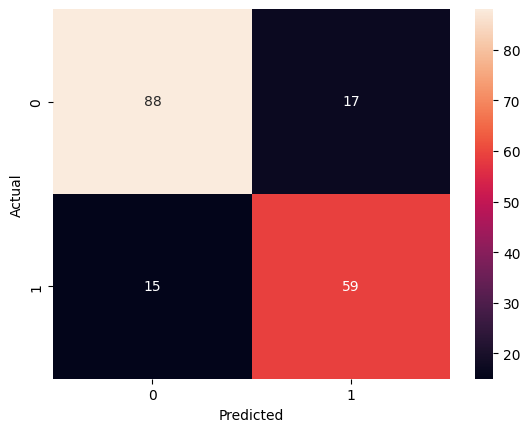

In [57]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [58]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.85      0.84      0.85       105
           1       0.78      0.80      0.79        74

    accuracy                           0.82       179
   macro avg       0.82      0.82      0.82       179
weighted avg       0.82      0.82      0.82       179



In [59]:
importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": model.coef_[0]
})

importance.sort_values(
    by="Coefficient",
    ascending=False
)

,Feature,Coefficient
13,Deck_E,1.023172
4,Fare,0.764526
20,Title_Mrs,0.618585
12,Deck_D,0.614191
14,Deck_F,0.352879
10,Deck_B,0.321089
5,FamilySize,-0.079324
11,Deck_C,-0.194549
8,Embarked_Q,-0.210571
16,Deck_T,-0.255031


In [60]:
importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": model.coef_[0]
})

importance.sort_values(
    by="Coefficient",
    ascending=False
)

,Feature,Coefficient
13,Deck_E,1.023172
4,Fare,0.764526
20,Title_Mrs,0.618585
12,Deck_D,0.614191
14,Deck_F,0.352879
10,Deck_B,0.321089
5,FamilySize,-0.079324
11,Deck_C,-0.194549
8,Embarked_Q,-0.210571
16,Deck_T,-0.255031


In [61]:
test_score = model.score(
    X_test,
    y_test
)

print(test_score)

0.8212290502793296


In [62]:
from sklearn.feature_selection import mutual_info_classif

mi = mutual_info_classif(X,y)



In [63]:
mi=pd.Series(mi, index=X.columns).sort_values(ascending=False)

In [64]:
mi

Title_Mr        0.152384
Sex_male        0.144657
Fare            0.125993
Pclass          0.098120
Title_Mrs       0.066630
Parch           0.041118
FamilySize      0.040414
Title_Miss      0.037725
Deck_Unknown    0.033334
SibSp           0.022098
Deck_D          0.021104
Embarked_S      0.019032
Embarked_Q      0.015539
Age             0.014854
IsAlone         0.000054
Deck_E          0.000000
Deck_B          0.000000
Deck_C          0.000000
Deck_T          0.000000
Deck_G          0.000000
Deck_F          0.000000
Title_Rare      0.000000
dtype: float64

In [65]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression

rfe = RFE(estimator=LogisticRegression(max_iter=1000),n_features_to_select=10)

In [66]:
rfe.fit(X_train, y_train)

,estimator,LogisticRegre...max_iter=1000)
,n_features_to_select,10
,step,1
,verbose,0
,importance_getter,'auto'
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1


In [67]:
selected_features = X_train.columns[rfe.support_]

In [68]:
selected_features

Index(['Pclass', 'Age', 'Embarked_S', 'Deck_B', 'Deck_D', 'Deck_E', 'Deck_F',
       'Title_Mr', 'Title_Mrs', 'Title_Rare'],
      dtype='object')